In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
processed_data = pd.read_csv(
    "../data/processed/spy_features.csv",
    index_col=0,
    parse_dates=True
)

1. Define features and target

In [3]:
FEATURES = [
    "ret_1d",
    "ret_5d",
    "ret_20d",
    "vol_20d",
    "ma_20_dist",
    "zscore_20d",
    "volume_zscore_20d",
    "ret_lag1",
    "ret_lag2",
    "ret_lag3"
]

In [4]:
TARGET = "next_return"

In [5]:
data = processed_data[
    FEATURES + [TARGET]
].dropna().copy()

In [6]:
X = data[FEATURES]
y = data[TARGET]

2. No random train test split

In [7]:
train = data.loc[: "2022-12-31"]
test = data.loc["2023-01-01":]

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [8]:
print(X_train.shape)
print(X_test.shape)

print(X_train.index.min(), X_train.index.max())
print(X_test.index.min(), X_test.index.max())

(1742, 10)
(751, 10)
2016-02-02 00:00:00 2022-12-30 00:00:00
2023-01-03 00:00:00 2025-12-30 00:00:00


3. LinearRegression

In [9]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

LinearRegression()

In [10]:
y_pred_linear = linear_model.predict(
    X_test
)

4. Check coefficients

In [11]:
coef_linear = pd.Series(
    linear_model.coef_,
    index=FEATURES
)

coef_linear.sort_values()

ret_1d              -0.193689
ret_lag3            -0.104234
ret_lag2            -0.042686
ma_20_dist          -0.012043
ret_20d             -0.001621
volume_zscore_20d   -0.000666
zscore_20d           0.000430
ret_lag1             0.024947
ret_5d               0.029310
vol_20d              0.044555
dtype: float64

In [12]:
linear_model.intercept_

np.float64(4.974102228475364e-05)

6. Regression metrics

In [13]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

In [14]:
linear_metrics = regression_metrics(
    y_test,
    y_pred_linear
)

linear_metrics

{'MSE': 9.338549489184628e-05,
 'RMSE': np.float64(0.009663617070840829),
 'MAE': 0.006699111451993079,
 'R2': -8.647424738494891e-06}

8. baseline

In [15]:
baseline_pred = np.full(
    len(y_test),
    y_train.mean()
)

In [16]:
baseline_metrics = regression_metrics(
    y_test,
    baseline_pred
)

baseline_metrics

{'MSE': 9.349513701765814e-05,
 'RMSE': np.float64(0.009669288340806584),
 'MAE': 0.006549196653017273,
 'R2': -0.0011827384766824878}

10. Ridge Regression

In [17]:
ridge_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "ridge",
        Ridge(alpha=1.0)
    )
])

In [18]:
ridge_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

In [19]:
y_pred_ridge = ridge_model.predict(
    X_test
)

In [20]:
ridge_metrics = regression_metrics(
    y_test,
    y_pred_ridge
)

ridge_metrics

{'MSE': 9.338294389094865e-05,
 'RMSE': np.float64(0.009663485079977547),
 'MAE': 0.006698839726020972,
 'R2': 1.8669697263939966e-05}

In [21]:
ridge_coef = pd.Series(
    ridge_model.named_steps["ridge"].coef_,
    index=FEATURES
)

ridge_coef.sort_values()

ret_1d              -0.002311
ret_lag3            -0.001243
volume_zscore_20d   -0.000711
ret_lag2            -0.000507
ma_20_dist          -0.000318
ret_20d             -0.000078
ret_lag1             0.000301
vol_20d              0.000317
zscore_20d           0.000536
ret_5d               0.000708
dtype: float64

Lasso Regression

In [22]:
lasso_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "lasso",
        Lasso(
            alpha=0.0001,
            max_iter=10000
        )
    )
])

In [23]:
lasso_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso', Lasso(alpha=0.0001, max_iter=10000))])

In [24]:
y_pred_lasso = lasso_model.predict(
    X_test
)

In [25]:
lasso_metrics = regression_metrics(
    y_test,
    y_pred_lasso
)

lasso_metrics

{'MSE': 9.342836980838696e-05,
 'RMSE': np.float64(0.00966583518421388),
 'MAE': 0.006679333251406638,
 'R2': -0.0004677689119452211}

In [26]:
lasso_coef = pd.Series(
    lasso_model.named_steps["lasso"].coef_,
    index=FEATURES
)

lasso_coef.sort_values()

ret_1d              -0.001888
ret_lag3            -0.000835
volume_zscore_20d   -0.000652
ret_lag2            -0.000035
ret_5d               0.000000
ret_20d             -0.000000
ma_20_dist          -0.000000
zscore_20d           0.000147
vol_20d              0.000226
ret_lag1             0.000588
dtype: float64

In [27]:
(lasso_coef == 0).sum()

np.int64(3)

16. check some alphas

In [28]:
alphas = [
    0.00001,
    0.0001,
    0.001,
    0.01,
    0.1,
    1.0
]

In [29]:
for alpha in alphas:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    mse = mean_squared_error(
        y_test,
        pred
    )

    print(
        f"alpha={alpha:<8} "
        f"MSE={mse:.8f}"
    )

alpha=1e-05    MSE=0.00009339
alpha=0.0001   MSE=0.00009339
alpha=0.001    MSE=0.00009339
alpha=0.01     MSE=0.00009339
alpha=0.1      MSE=0.00009339
alpha=1.0      MSE=0.00009338


In [30]:
results = pd.DataFrame({
    "Baseline": baseline_metrics,
    "Linear": linear_metrics,
    "Ridge": ridge_metrics,
    "Lasso": lasso_metrics
}).T

results

,MSE,RMSE,MAE,R2
Baseline,0.000093,0.009669,0.006549,-0.001183
Linear,0.000093,0.009664,0.006699,-0.000009
Ridge,0.000093,0.009663,0.006699,0.000019
Lasso,0.000093,0.009666,0.006679,-0.000468


19 prediction vs actual

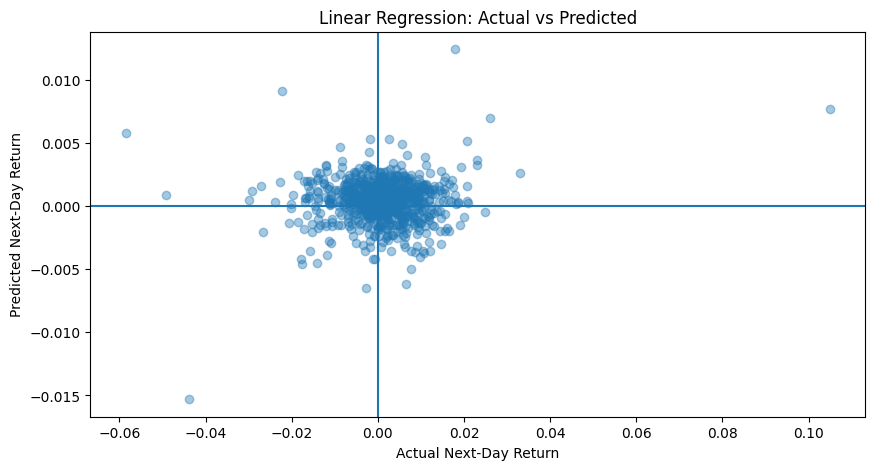

In [31]:
plt.figure(figsize=(10, 5))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.4
)

plt.xlabel("Actual Next-Day Return")
plt.ylabel("Predicted Next-Day Return")

plt.title(
    "Linear Regression: Actual vs Predicted"
)

plt.axhline(0)
plt.axvline(0)

plt.show()

20. prediction distribution

In [32]:
print(
    "Actual std:",
    y_test.std()
)

print(
    "Prediction std:",
    np.std(y_pred_linear)
)

Actual std: 0.009670015525906033
Prediction std: 0.0018071118710361155


21. Finance RMSE 

In [33]:
from scipy.stats import spearmanr

In [34]:
rho_linear, p_linear = spearmanr(
    y_pred_linear,
    y_test
)

print(
    "Prediction IC:",
    rho_linear
)

print(
    "p-value:",
    p_linear
)

Prediction IC: -0.021419667393829504
p-value: 0.5578203037326597


compare IC

In [35]:
models_pred = {
    "Linear": y_pred_linear,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso
}

for name, pred in models_pred.items():

    rho, p = spearmanr(
        pred,
        y_test
    )

    print(
        f"{name:10s} "
        f"IC={rho:.4f}, "
        f"p={p:.4f}"
    )

Linear     IC=-0.0214, p=0.5578
Ridge      IC=-0.0214, p=0.5586
Lasso      IC=-0.0138, p=0.7058


23. Directional accuracy

In [36]:
direction_actual = (
    y_test > 0
)

direction_pred = (
    y_pred_linear > 0
)

In [37]:
direction_accuracy = (
    direction_actual == direction_pred
).mean()

direction_accuracy

np.float64(0.5059920106524634)

24. 比较 coefficient stability

In [38]:
linear_coef = pd.Series(
    linear_model.coef_,
    index=FEATURES,
    name="Linear"
)

In [39]:
ridge_coef = pd.Series(
    ridge_model.named_steps["ridge"].coef_,
    index=FEATURES,
    name="Ridge"
)

In [40]:
lasso_coef = pd.Series(
    lasso_model.named_steps["lasso"].coef_,
    index=FEATURES,
    name="Lasso"
)

In [41]:
coef_table = pd.concat(
    [
        linear_coef,
        ridge_coef,
        lasso_coef
    ],
    axis=1
)

coef_table

,Linear,Ridge,Lasso
ret_1d,-0.193689,-0.002311,-0.001888
ret_5d,0.029310,0.000708,0.000000
ret_20d,-0.001621,-0.000078,-0.000000
vol_20d,0.044555,0.000317,0.000226
ma_20_dist,-0.012043,-0.000318,-0.000000
zscore_20d,0.000430,0.000536,0.000147
volume_zscore_20d,-0.000666,-0.000711,-0.000652
ret_lag1,0.024947,0.000301,0.000588
ret_lag2,-0.042686,-0.000507,-0.000035
ret_lag3,-0.104234,-0.001243,-0.000835


In [42]:
linear_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

linear_scaled.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()), ('linear', LinearRegression())])

In [43]:
linear_scaled_coef = pd.Series(
    linear_scaled.named_steps["linear"].coef_,
    index=FEATURES
)

In [44]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

regression_predictions = pd.DataFrame(
    {
        "actual_return": y_test,
        "linear_pred": y_pred_linear,
        "ridge_pred": y_pred_ridge,
        "lasso_pred": y_pred_lasso,
    },
    index=X_test.index
)

regression_predictions.head()

regression_predictions.to_csv(
    output_dir / "regression_predictions.csv"
)

In [45]:

regression_predictions.head()

,actual_return,linear_pred,ridge_pred,lasso_pred
Date,,,,
2023-01-03,0.007720,0.001839,0.001841,0.002093
2023-01-04,-0.011413,-0.002764,-0.002759,-0.002202
2023-01-05,0.022932,0.003648,0.003643,0.003048
2023-01-06,-0.000567,-0.004199,-0.004195,-0.003795
2023-01-09,0.007013,0.001859,0.001860,0.001744
